## School Diet

A school wants to estimate the effect of a diet on boys and girls' weight. For this purpose the school first measures the weight of all students at the beginning of the school year (W_{0}) then another measurement is taken six months later (W_{1}).

Generate $n=100$ observations from the following statistical model:

$$
S \sim \text{Bernoulli}(0.5) \\
W_0 \sim \text{Normal}(\mu_i, \sigma_0) \\
\mu_i = \beta_0 + \beta_1 \cdot S_i \\
W_1 = W_0 + \text{Normal}(0, \sigma_e)
$$

- Choose values for the parameters of the model ($\beta_0$, $\beta_1$, $\sigma_0$, $\sigma_e$) that you think are reasonable. Use the `rnorm` function to generate the normally distributed variables for weight at time 0 and time 1, and the `rbinom` function to generate the binary variable for sex (S).
- Visualize the data and adjust your parameters until the generated data looks reasonable. You can use a scatter plot to visualize the relationship between weight at time 0 and time 1, and color the points by sex to see if there are any differences between boys and girls.

In [1]:
suppressPackageStartupMessages(library(tidyverse))

n <- 10000

S <- rbinom(n, size = 1, prob = 0.5)
W0 <- rnorm(n, mean = 60 + 10 * S, sd = 5)
W1 <- W0 + rnorm(n, mean = 0, sd = 2)

diet <- tibble(S = S, W0 = W0, W1 = W1, Y = W1 - W0)

diet |> head()

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”


S,W0,W1,Y
<int>,<dbl>,<dbl>,<dbl>
1,68.67107,66.17020,-2.5008730
0,59.77064,58.83133,-0.9393115
1,62.99498,61.46647,-1.5285081
0,53.02647,50.64503,-2.3814359
0,66.10821,68.38752,2.2793013
1,72.49513,74.12448,1.6293491


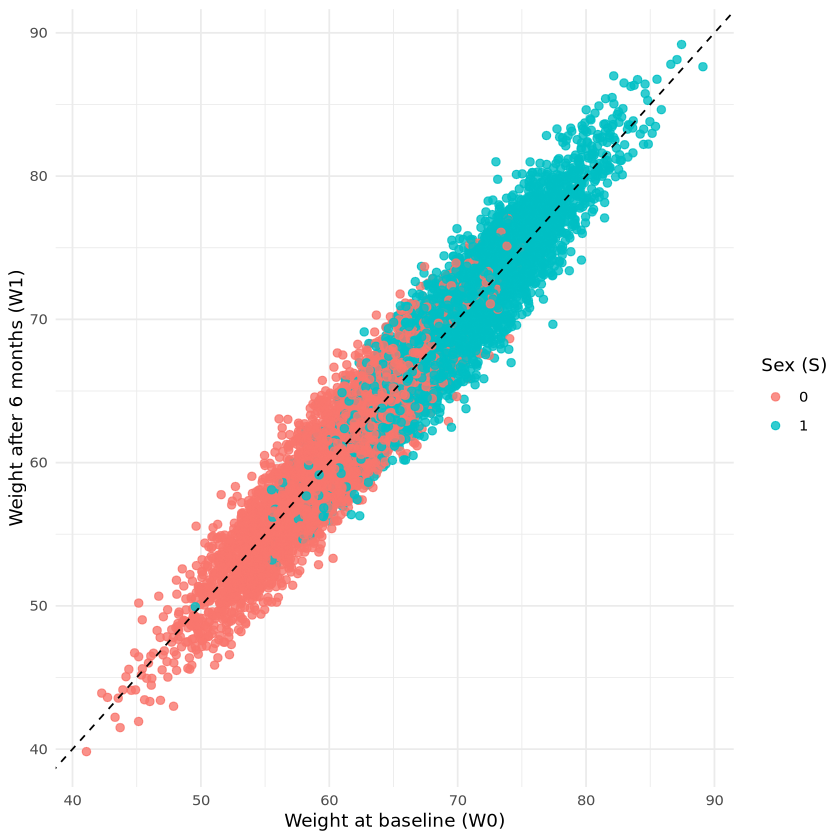

In [ ]:
ggplot(diet, aes(x = W0, y = W1, color = factor(S))) +
    geom_point(alpha = 0.8, size = 2) +
    labs(
        x = "Weight at baseline (W0)",
        y = "Weight after 6 months (W1)",
        color = "Sex (S)"
    ) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "black") +
    theme_minimal()

## Analysis

Now pretend that you don't know the data generating process. You only see the end results (the dataset you generated) and you want to analyze it to understand the relationships between weight gain (the difference between the weight after six months and the weight at the beginning of the school year) and sex. In particular you want to research the following question:

```
Is there a difference in weight gain between boys and girls?
```

You want to approach this question by fitting a linear regression model where the dependent variable is the weight gain (W_1 - W_0) and the independent variable is the sex (S).

Should you condition on the initial weight? Do you reach different conclusions if you do or do not condition on the initial weight? Why?

In [ ]:
fit_0 <- lm(Y ~ S, data = diet)
fit_0 |> summary()


Call:
lm(formula = Y ~ S, data = diet)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.7397 -1.3656 -0.0169  1.3559  8.0435 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)
(Intercept) -0.017795   0.028499  -0.624    0.532
S           -0.005191   0.040160  -0.129    0.897

Residual standard error: 2.008 on 9998 degrees of freedom
Multiple R-squared:  1.671e-06,	Adjusted R-squared:  -9.835e-05 
F-statistic: 0.01671 on 1 and 9998 DF,  p-value: 0.8972


In [ ]:
fit_1 <- lm(Y ~ 1 + S + W0, data = diet)
fit_1 |> summary()


Call:
lm(formula = Y ~ 1 + S + W0, data = diet)

Residuals:
   Min     1Q Median     3Q    Max 
-7.771 -1.369 -0.012  1.357  8.031 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)
(Intercept) -0.273350   0.243224  -1.124    0.261
S           -0.048307   0.057215  -0.844    0.399
W0           0.004262   0.004029   1.058    0.290

Residual standard error: 2.008 on 9997 degrees of freedom
Multiple R-squared:  0.0001136,	Adjusted R-squared:  -8.641e-05 
F-statistic: 0.568 on 2 and 9997 DF,  p-value: 0.5667
